In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import csv, json
from sklearn.metrics import root_mean_squared_error,mean_squared_error
import numpy as np

from statsmodels.stats.weightstats import ttost_ind
import statsmodels.formula.api as smf
import statsmodels.api as sm
# use the dedicated RMSE function (sklearn ≥1.4)
from sklearn.metrics import root_mean_squared_error
import sys, inspect, sklearn, sklearn.metrics as M


In [3]:
# !pip install statsmodels

In [5]:

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("Signature:", inspect.signature(M.mean_squared_error))
print("From module:", M.mean_squared_error.__module__)
print("Kernel executable:", sys.executable)

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]
scikit-learn: 1.5.1
Signature: (y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', squared='deprecated')
From module: sklearn.metrics._regression
Kernel executable: /opt/anaconda3/bin/python


# Read me

This script relies on the data being chunked by "DataChunking_sigmark_overheadtest.ipynb" and that we have obtained one csv file for each of the tests. If in doubt, check your "ChunkedData" folder.

The following imports the chunked data and provides us with two dataframes:
- dfs which holds the energy data for all the test
- df_powers holds all the power measurements for all the tests

After the import, the data is ready for your 

In [38]:
input_directory = '../ChunkedData_Siglent'
data_output_directory = '../EnergyData/'
output_directory = '../Results/'

In [10]:
# this part reads the chunked data files related to the 

In [12]:
ls ../ChunkedData_Siglent

10_0_0.03_1765649522678_1062_siglent.1766046701688.CH1.csv
10_0_0.04_1765649420133_1061_siglent.1766046701688.CH1.csv
10_0_0.05_1765649317554_1060_siglent.1766046701688.CH1.csv
10_0_0.1_1765649214926_1059_siglent.1766046701688.CH1.csv
10_0_0.2_1765649112381_1058_siglent.1766046701688.CH1.csv
10_0_0.5_1765649009353_1057_siglent.1766046701688.CH1.csv
10_0_0_1765648703719_1054_siglent.1766046701688.CH1.csv
10_0_1_1765648906807_1056_siglent.1766046701688.CH1.csv
10_0_2_1765648804262_1055_siglent.1766046701688.CH1.csv
10_100_0.03_1765660574369_1170_siglent.1766046701688.CH1.csv
10_100_0.04_1765660471827_1169_siglent.1766046701688.CH1.csv
10_100_0.05_1765660369249_1168_siglent.1766046701688.CH1.csv
10_100_0.1_1765660266621_1167_siglent.1766046701688.CH1.csv
10_100_0.2_1765660164080_1166_siglent.1766046701688.CH1.csv
10_100_0.5_1765660061052_1165_siglent.1766046701688.CH1.csv
10_100_0_1765659755429_1162_siglent.1766046701688.CH1.csv
10_100_1_1765659958510_1164_siglent.1766046701688.CH1.csv
10

In [14]:
test_file = "../ChunkedData_Siglent/10_0_0.03_1765649522678_1062_siglent.1766046701688.CH1.csv"

pd.read_csv(test_file,nrows=1,header=0)

# we want to  keep id2, exp_duration, count as  test, exp_duration, no_of_messages

,round,load,period,start_time,id,channelId,exp_duration,end_time,experiment
0,10,0,0.03,1765649522678,1061,CH1,80025,1765649602703,stress-ng


In [22]:
df_test = pd.read_csv(test_file,nrows=1,header=0) #,usecols = [1,3,6,7],names=['period','load','exp_duration','experiment'])
display(df_test)
df_test.columns

,round,load,period,start_time,id,channelId,exp_duration,end_time,experiment
0,10,0,0.03,1765649522678,1061,CH1,80025,1765649602703,stress-ng


Index(['round', 'load', 'period', 'start_time', 'id', 'channelId',
       'exp_duration', 'end_time', 'experiment'],
      dtype='object')

In [321]:
pd.read_csv('../ChunkedData_Siglent/sigmark_0.01_1764769841716_10_0_siglent.1764836347156.CH1_homemade_script_energylogger_overhead.csv',skiprows=2, names=['timestamp','channel','action','payload'])



,timestamp,channel,action,payload
0,1764861092478,CH1,POWER,2.45
1,1764861092483,CH1,POWER,2.45
2,1764861092491,CH1,POWER,2.45
3,1764861092497,CH1,POWER,2.45
4,1764861092503,CH1,POWER,2.45
...,...,...,...,...
14164,1764861172474,CH1,POWER,2.85
14165,1764861172478,CH1,POWER,2.85
14166,1764861172484,CH1,POWER,2.85
14167,1764861172490,CH1,POWER,2.85


In [50]:
#import all the CSV files

# (a) Read from row 3 and on into df and calculate energy consumption
# (b) Read the first two lines with meta data, add the calculated energy consumption and concat to the existing
ID = 0
list_of_metadataframes = []
list_of_dataframes = []
for input_file in os.listdir(input_directory):
    file_path = input_directory+'/'
    file_name = os.path.basename(input_file)
    #print(file_name)
    if file_name.endswith('.csv'):
        df = pd.read_csv(file_path+file_name,skiprows=2, names=['timestamp','channel','action','payload'])
        # print(file_path+file_name,df['timestamp'].dtypes)
        df['time'] = (df['timestamp']-df['timestamp'].min()) / 1000
        df['ID'] = ID
        x = df['time']
        y = df['payload']
        y_int = integrate.cumulative_trapezoid(y, x, initial=0)
        #plt.plot(x, y_int)
        #plt.plot(x,y)
        #plt.savefig('')
        #plt.show()
        energy = y_int[-1]
        df_main = pd.read_csv(file_path+file_name,nrows=1,header=0) #,usecols = [1,3,6,7],names=['period','load','exp_duration','experiment'])
        df_main['duration']= df_main['exp_duration'] / 1000  # in seconds
        df_main['energy']=energy  # in joules
        df_main['power_avg']= energy*1000/df_main['exp_duration'] # in Watt
        df_main['ID'] = ID
        # print(df_main)
        df['load']=df_main['load'][0]
        df['experiment']=df_main['experiment'][0]
        df['period']=df_main['period'][0]
        df['ID'] = ID
        list_of_metadataframes.append(df_main)
        list_of_dataframes.append(df)
        ID = ID + 1

#dfs = pd.concat(list_of_metadataframes)
#df_power = pd.concat(list_of_dataframes)


In [51]:
df_power = pd.concat(list_of_dataframes)

In [54]:
dfs = pd.concat(list_of_metadataframes)

In [56]:
df_power.head(5)

,timestamp,channel,action,payload,time,ID,load,experiment,period
0,1765835256698,CH1,POWER,2.55,0.000,0,50,stress-ng,0.1
1,1765835256702,CH1,POWER,2.55,0.004,0,50,stress-ng,0.1
2,1765835256706,CH1,POWER,2.55,0.008,0,50,stress-ng,0.1
3,1765835256711,CH1,POWER,2.55,0.013,0,50,stress-ng,0.1
4,1765835256715,CH1,POWER,2.55,0.017,0,50,stress-ng,0.1


In [58]:
dfs =pd.concat(list_of_metadataframes)

In [60]:
dfs = dfs.sort_values(by=['experiment','period'])
dfs = dfs.reset_index(drop=True)

In [62]:
dfs.to_csv(data_output_directory+'sigless_energy_data.csv')

In [64]:
dfs.head(4)

,round,load,period,start_time,id,channelId,exp_duration,end_time,experiment,duration,energy,power_avg,ID
0,2,80,0.0,1765562129596,207,CH1,80022,1765562209618,stress-ng,80.022,323.832000,4.046787,9
1,20,100,0.0,1765779485328,2331,CH1,80024,1765779565352,stress-ng,80.024,338.666675,4.232064,11
2,20,20,0.0,1765772118499,2259,CH1,80022,1765772198521,stress-ng,80.022,267.376900,3.341292,13
3,12,20,0.0,1765676335327,1323,CH1,80023,1765676415350,stress-ng,80.023,267.284625,3.340098,14


In [128]:
dfs['N_loggings'] = np.where(
    dfs["period"] == 0.0,
    0,  # if period == 0.0 → 0 logs (no energy logging)
    (dfs["duration"] // dfs["period"])  # otherwise normal formula
)
dfs['frequency'] = np.where(
    dfs["period"] == 0.0,
    0,  # if period == 0.0 → 0 logs (no energy logging)
    (1.0/dfs["period"])  # otherwise normal formula
)

In [130]:

pl_summary = (
dfs
.groupby(["period","load",'experiment'], as_index=False)
.agg(
    power_mean   = ("power_avg","mean"),
    power_std    = ("power_avg","std"),
    energy_mean  = ("energy","mean"),
    energy_std   = ("energy","std"),
    duration_mean= ("duration","mean"),
    duration_std = ("duration","std"),
    loggings_mean = ("N_loggings","mean"),
    loggings_std = ("N_loggings","std"),
    runs         = ("power_avg","size"),
    frequency_mean= ('frequency','mean')
)
)


In [132]:
pl_summary

,period,load,experiment,power_mean,power_std,energy_mean,energy_std,duration_mean,duration_std,loggings_mean,loggings_std,runs,frequency_mean
0,0.0,0,stress-ng,2.571162,0.024330,205.760930,1.938677,80.026457,0.004133,0.0,0.0,35,0.0
1,0.0,5,stress-ng,2.992413,0.049732,239.655002,4.081226,80.087314,0.225433,0.0,0.0,35,0.0
2,0.0,10,stress-ng,3.167368,0.036088,253.537117,2.832660,80.046886,0.097628,0.0,0.0,35,0.0
3,0.0,15,stress-ng,3.249660,0.030669,260.077709,2.466201,80.032257,0.043457,0.0,0.0,35,0.0
4,0.0,20,stress-ng,3.324504,0.019943,266.095627,1.579838,80.040743,0.044458,0.0,0.0,35,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,2.0,60,stress-ng,3.820056,0.019138,305.719098,1.529856,80.030000,0.011301,40.0,0.0,35,0.5
113,2.0,70,stress-ng,3.929373,0.022802,314.482263,1.828986,80.033686,0.010070,40.0,0.0,35,0.5
114,2.0,80,stress-ng,4.030433,0.019800,322.552091,1.588069,80.029143,0.006010,40.0,0.0,35,0.5
115,2.0,90,stress-ng,4.136559,0.017530,331.035256,1.405061,80.026714,0.004281,40.0,0.0,35,0.5


In [108]:
pl_summary.to_csv(output_directory+'summary.csv')

<Axes: xlabel='frequency_mean', ylabel='energy_mean'>

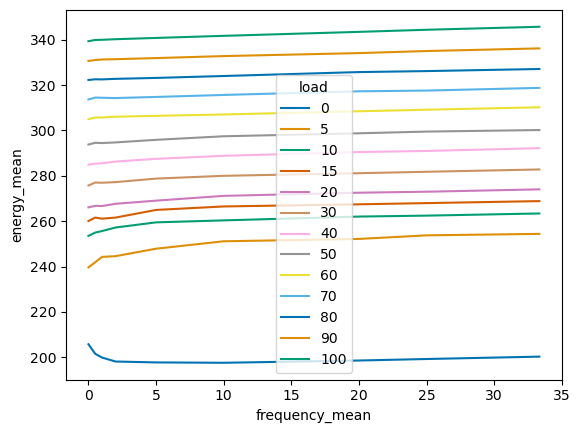

In [134]:
sns.lineplot(data=pl_summary,x='frequency_mean',y='energy_mean',hue='load',legend='full',palette='colorblind')

In [156]:
import matplotlib


<module 'matplotlib.markers' from '/opt/anaconda3/lib/python3.12/site-packages/matplotlib/markers.py'>

<Axes: xlabel='frequency', ylabel='energy'>

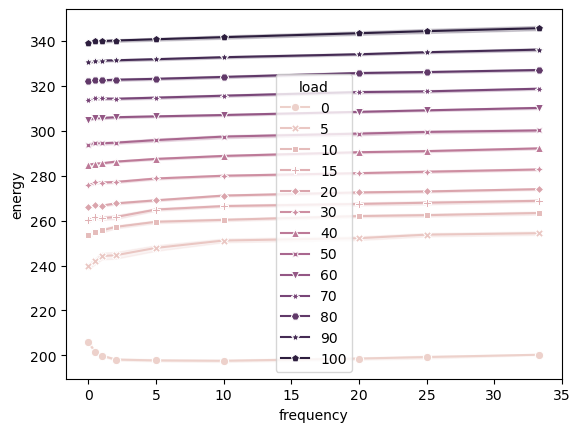

In [170]:
sns.lineplot(data=dfs,x='frequency',y='energy',hue='load',legend='full', style="load", markers = True, dashes=False)

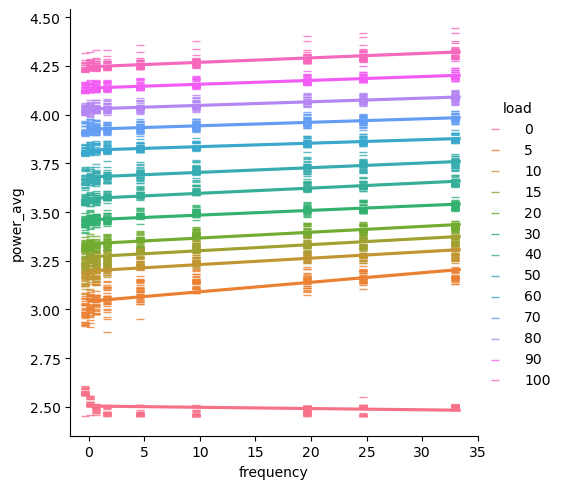

In [190]:
sns.lmplot(data=dfs,x='frequency',y='power_avg',hue='load',legend='full',markers=False)

<Axes: xlabel='frequency', ylabel='power_avg'>

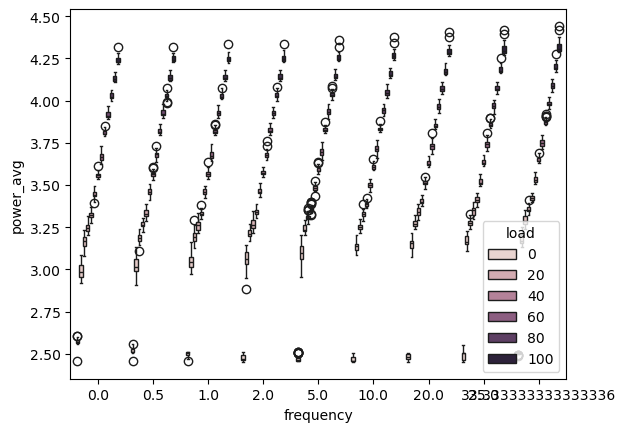

In [142]:
sns.boxplot(data=dfs, hue='load', x='frequency', y='power_avg')

In [196]:

# 1) Calculate baseline mean power from measurements with 0 frequency
baseline = (
    dfs[dfs["period"] == 0.0]
    .groupby(["load"])["power_avg"]
    .mean()
    .rename("P0_data")
    .reset_index()
)
# 2) merge this data onto the dfs
dfs_with = dfs.merge(baseline, on=["load"], how="left")

# 3) Calculate overhead from data
dfs_with["power_overhead_data"] = dfs_with["power_avg"] - dfs_with["P0_data"]



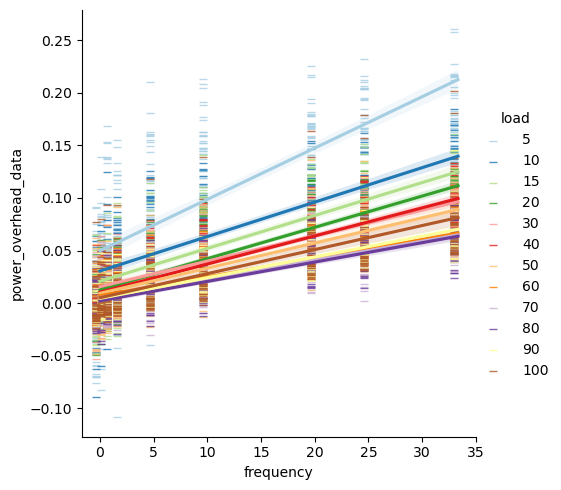

In [206]:
sns.lmplot(data=dfs_with[dfs_with['load']>0],x='frequency',y='power_overhead_data',hue='load',legend='full',markers=False,palette="Paired")

In [208]:
dfs_with[dfs_with['load']>0].groupby('load')['power_overhead_data'].describe()

,count,mean,std,min,25%,50%,75%,max
load,,,,,,,,
5,315.0,0.102292,0.077014,-0.108553,0.046661,0.116631,0.163021,0.260149
10,315.0,0.065743,0.050598,-0.089150,0.028260,0.071505,0.101828,0.184480
15,315.0,0.054372,0.047467,-0.047877,0.012246,0.059418,0.089169,0.160792
20,315.0,0.044513,0.040601,-0.049720,0.008873,0.042145,0.075926,0.128554
30,315.0,0.041723,0.035176,-0.052661,0.014931,0.040810,0.067531,0.131338
40,315.0,0.039158,0.036445,-0.027042,0.007827,0.035917,0.067194,0.132896
50,315.0,0.035026,0.038006,-0.048483,0.006258,0.034907,0.061841,0.135836
60,315.0,0.026177,0.027141,-0.023077,0.002857,0.024479,0.045812,0.112297
70,315.0,0.024570,0.029099,-0.030294,0.000832,0.022673,0.045974,0.100979


In [210]:
dfs_with[dfs_with['load']>0].groupby('load')['power_avg'].describe()

,count,mean,std,min,25%,50%,75%,max
load,,,,,,,,
5,315.0,3.094704,0.077014,2.883860,3.039073,3.109044,3.155434,3.252562
10,315.0,3.233111,0.050598,3.078217,3.195628,3.238872,3.269196,3.351847
15,315.0,3.304032,0.047467,3.201783,3.261906,3.309078,3.338829,3.410452
20,315.0,3.369017,0.040601,3.274784,3.333377,3.366649,3.400430,3.453058
30,315.0,3.486274,0.035176,3.391890,3.459481,3.485361,3.512081,3.575889
40,315.0,3.598306,0.036445,3.532106,3.566975,3.595064,3.626342,3.692044
50,315.0,3.705525,0.038006,3.622016,3.676757,3.705406,3.732341,3.806335
60,315.0,3.836977,0.027141,3.787722,3.813657,3.835279,3.856612,3.923097
70,315.0,3.944116,0.029099,3.889251,3.920378,3.942218,3.965519,4.020524


In [228]:
df = dfs_with.query("load > 0").copy()

means = (df.groupby(["load","frequency"])["power_avg"]
           .mean()
           .unstack("frequency")
           .sort_index(axis=1))

baseline = means[0.0]
delta = means.sub(baseline, axis=0)          # absolute overhead (W)
pct   = delta.div(baseline, axis=0) * 100    # relative overhead (%)

display(delta.round(3))
display(pct.round(2))

frequency,0.000000,0.500000,1.000000,2.000000,5.000000,10.000000,20.000000,25.000000,33.333333
load,,,,,,,,,
5,0.0,0.030,0.059,0.063,0.104,0.146,0.157,0.175,0.185
10,0.0,0.018,0.026,0.046,0.075,0.085,0.106,0.111,0.123
15,0.0,0.019,0.013,0.018,0.060,0.080,0.092,0.098,0.109
20,0.0,0.008,0.007,0.018,0.036,0.064,0.080,0.087,0.100
30,0.0,0.016,0.016,0.019,0.038,0.053,0.068,0.076,0.088
40,0.0,0.006,0.009,0.018,0.032,0.050,0.070,0.077,0.091
50,0.0,0.010,0.008,0.011,0.026,0.046,0.062,0.072,0.080
60,0.0,0.009,0.009,0.013,0.018,0.025,0.043,0.052,0.065
70,0.0,0.010,0.009,0.008,0.013,0.025,0.045,0.049,0.063


frequency,0.000000,0.500000,1.000000,2.000000,5.000000,10.000000,20.000000,25.000000,33.333333
load,,,,,,,,,
5,0.0,1.01,1.98,2.12,3.49,4.87,5.25,5.86,6.19
10,0.0,0.57,0.82,1.46,2.38,2.69,3.35,3.51,3.90
15,0.0,0.58,0.39,0.56,1.86,2.46,2.83,3.03,3.36
20,0.0,0.25,0.23,0.56,1.09,1.91,2.41,2.61,2.99
30,0.0,0.48,0.46,0.54,1.11,1.55,1.98,2.22,2.57
40,0.0,0.18,0.24,0.50,0.91,1.39,1.97,2.15,2.56
50,0.0,0.26,0.23,0.31,0.72,1.25,1.69,1.95,2.18
60,0.0,0.24,0.24,0.35,0.47,0.67,1.14,1.36,1.71
70,0.0,0.25,0.23,0.19,0.34,0.63,1.14,1.24,1.62


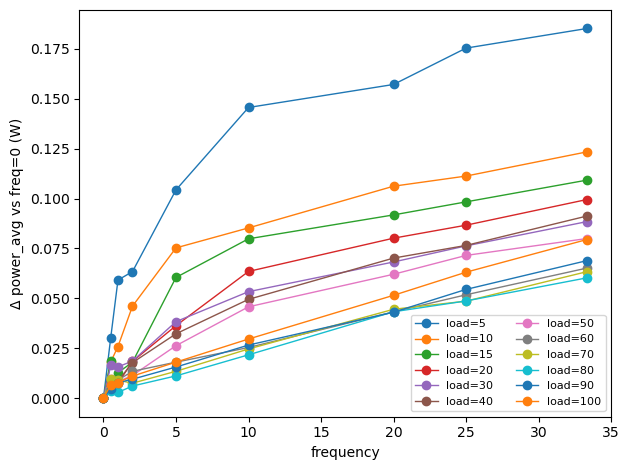

In [230]:
freqs = delta.columns.to_numpy()

plt.figure()
for load in delta.index:
    plt.plot(freqs, delta.loc[load].to_numpy(), marker="o", linewidth=1, label=f"load={load}")
plt.xlabel("frequency")
plt.ylabel("Δ power_avg vs freq=0 (W)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


# Nilma and Jespers Evaluation

The above imports the chunked data and provides us with two dataframes:
- dfs which holds the energy data for all the test
- df_powers holds all the power measurements for all the tests

1. Ultimately, we want to find out how much energy the raspberry pi is using per tick. 
2. We need to verify whether we can trust the data. 

['sleep' 'stress-ng']


<Axes: xlabel='period', ylabel='energy'>

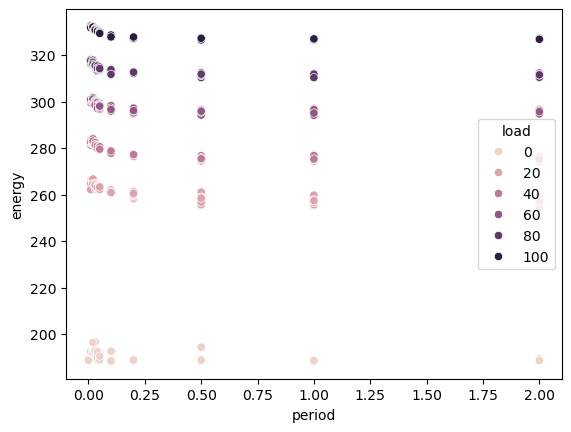

In [384]:
# first, we want to know how much energy is used for each number_of_messages
print(dfs['experiment'].unique())
sns.scatterplot(data= dfs, x='period',y='energy',hue='load',markers='experiment')

<Axes: xlabel='period', ylabel='power_avg'>

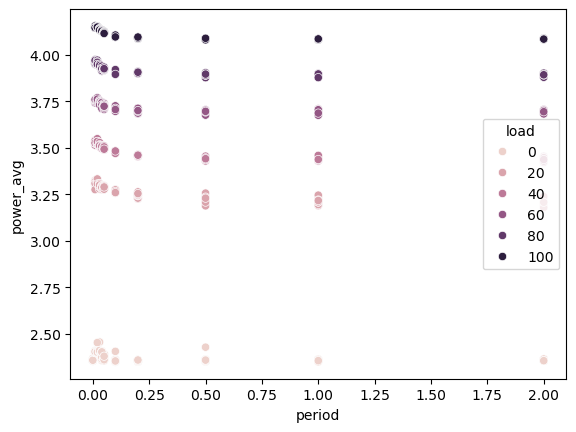

In [386]:
sns.scatterplot(data= dfs, x='period',y='power_avg',hue='load',markers='experiment')

<Axes: xlabel='time', ylabel='payload'>

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


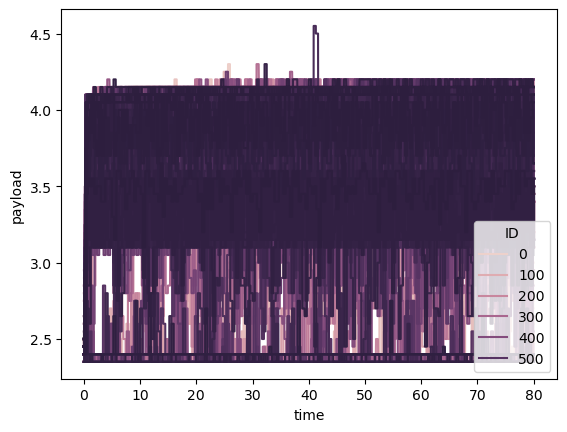

In [99]:
sns.lineplot(data=df_powers, x='time', y='payload',hue= 'ID')

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


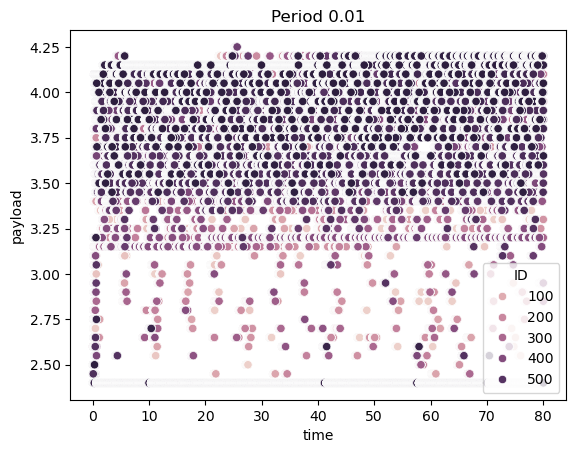

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


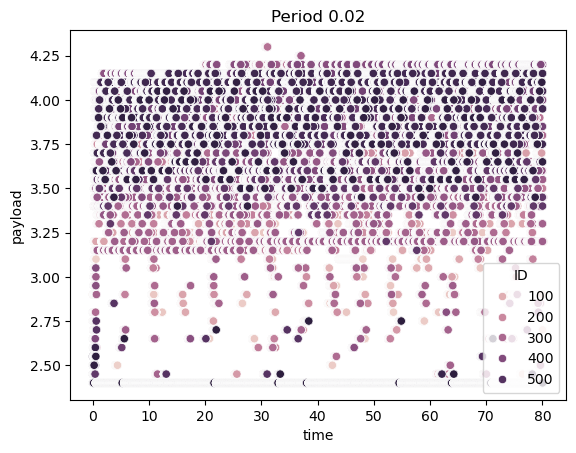

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


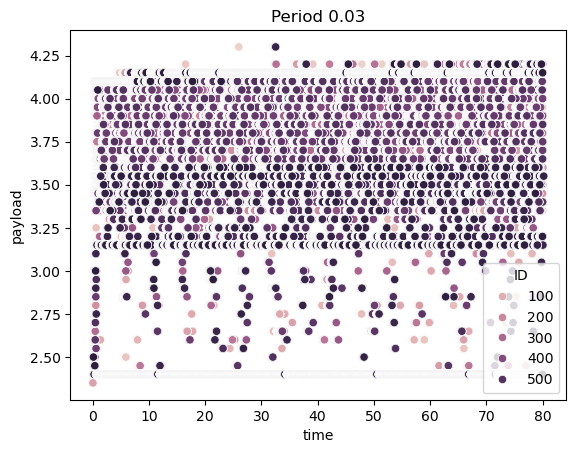

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


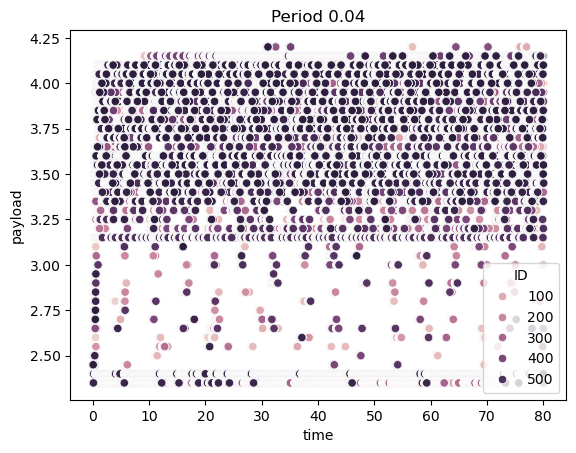

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


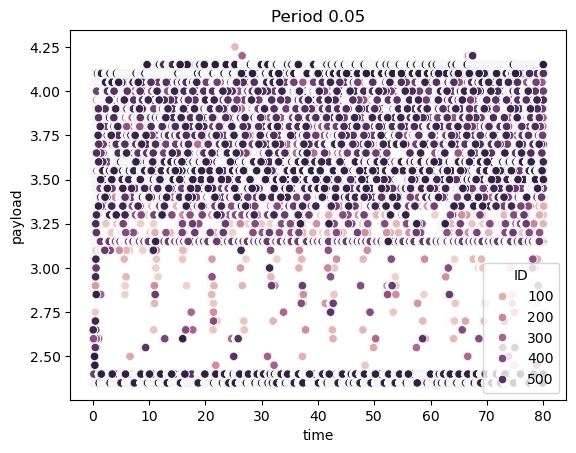

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


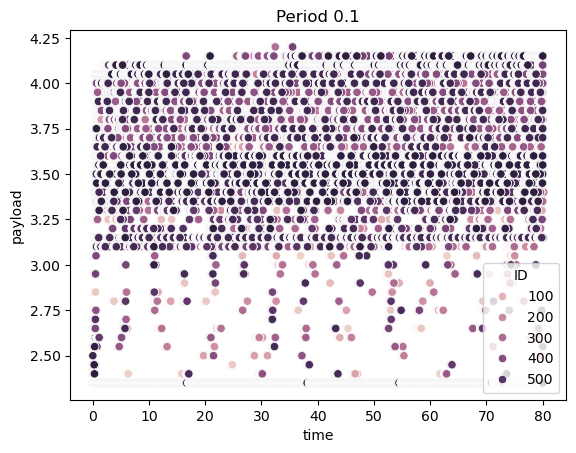

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


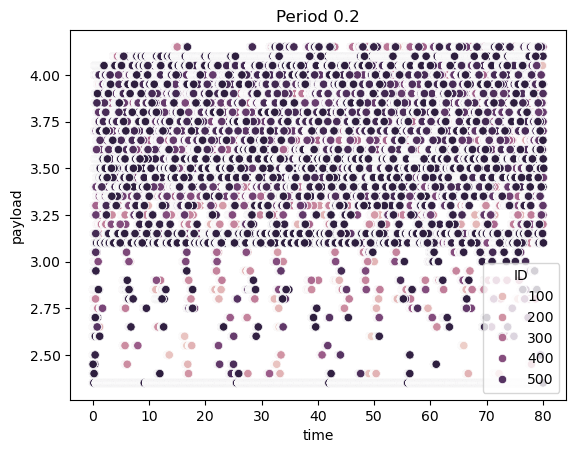

KeyboardInterrupt: 

In [105]:
df_powers_groupbytest = df_powers.groupby('period')

for test_, df in df_powers_groupbytest:
    sns.scatterplot(data=df, x='time', y='payload',hue= 'ID')
    plt.title(f"Period {test_}")
    plt.show()

In [ ]:
sns.scatterplot(data=df_powers, x='timestamp', y='payload',hue= 'period')

In [106]:
dfs.to_csv(output_directory+"sigless_energy_summary.csv")


### The Best-fit Global Model

$\text{energy} = a \cdot \text{number of messages} + b$

- $a$: baseline slope (effect of sending a message).
- $b$: global intercept (baseline energy when number of messages = 0).

R-squared (R²) is defined as a number that tells you how well the independent variable(s) in a statistical model explains the variation in the dependent variable. It ranges from 0 to 1, where 1 indicates a perfect fit of the model to the data.

While R² is often between 0 and 1, it can be negative when the model performs worse than predicting the mean of the data.

In [43]:
dfs= dfs[dfs['energy']<200]

                            OLS Regression Results                            
Dep. Variable:                 energy   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     677.6
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           1.34e-12
Time:                        10:03:21   Log-Likelihood:                -7.5278
No. Observations:                  15   AIC:                             19.06
Df Residuals:                      13   BIC:                             20.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        189.0883      0.154   1226.

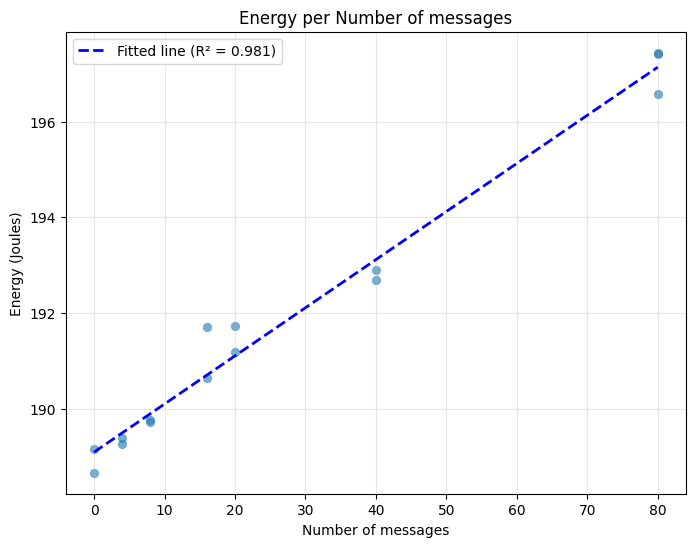

In [44]:
model = smf.ols("energy ~ no_of_messages", data=dfs).fit()
print(model.summary())

# Scatterplot of error vs duration
plt.figure(figsize=(8,6))
sns.scatterplot(x="no_of_messages", y="energy", data=dfs, alpha=0.6, edgecolor=None)

# Regression line (from statsmodels fit)
x_vals = np.linspace(dfs["no_of_messages"].min(), dfs["no_of_messages"].max(), 200)
y_vals = model.params['Intercept'] + model.params['no_of_messages']*x_vals  # from the regression model

r2_text = f"Fitted line (R² = {model.rsquared:.3f})"
plt.plot(x_vals, y_vals, color="blue", linewidth=2, linestyle='--',label=r2_text)

plt.title("Energy per Number of messages")
plt.xlabel("Number of messages")
plt.ylabel("Energy (Joules)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(output_directory+'energy_pr_no_of_message.png')
plt.show()